<a href="https://colab.research.google.com/github/toobajaved/GraphBasedMovieRecommendation/blob/main/01_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load
ratings = pd.read_csv('./ratings.csv')
movies = pd.read_csv('./movies.csv')

# Basic counts
print(f"Ratings: {len(ratings)}")
print(f"Users:   {ratings['userId'].nunique()}")
print(f"Movies:  {ratings['movieId'].nunique()}")
print(f"\nRating range: {ratings['rating'].min()} – {ratings['rating'].max()}")
print(f"\nratings.head():\n{ratings.head()}")

Ratings: 100836
Users:   610
Movies:  9724

Rating range: 0.5 – 5.0

ratings.head():
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931


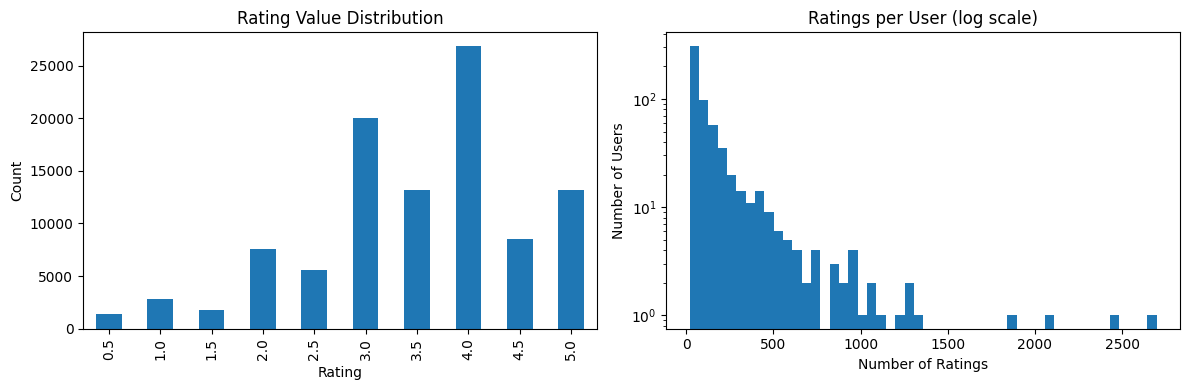

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Rating value distribution
ratings['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0])
axes[0].set_title('Rating Value Distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

# Plot 2: Ratings per user (log scale)
ratings_per_user = ratings.groupby('userId').size()
axes[1].hist(ratings_per_user, bins=50)
axes[1].set_yscale('log')
axes[1].set_title('Ratings per User (log scale)')
axes[1].set_xlabel('Number of Ratings')
axes[1].set_ylabel('Number of Users')

plt.tight_layout()
plt.savefig('./milestone1_plots.png', dpi=150)
plt.show()

In [7]:
# Positive interaction threshold analysis
positive = ratings[ratings['rating'] >= 4.0]
print(f"Positive interactions (≥4.0): {len(positive)} ({len(positive)/len(ratings)*100:.1f}%)")

# Sparsity
n_users = ratings['userId'].nunique()
n_movies = ratings['movieId'].nunique()
sparsity = 1 - (len(ratings) / (n_users * n_movies))
print(f"Graph sparsity: {sparsity:.4f}")

Positive interactions (≥4.0): 48580 (48.2%)
Graph sparsity: 0.9830


In [8]:
# Avg ratings per movie — useful context for graph degree analysis later
ratings_per_movie = ratings.groupby('movieId').size()
print(f"Avg ratings per movie: {ratings_per_movie.mean():.1f}")
print(f"Median: {ratings_per_movie.median():.1f}")
print(f"Movies with only 1 rating: {(ratings_per_movie == 1).sum()}")

# Positive interactions per user — relevant for negative sampling design
pos_per_user = ratings[ratings['rating'] >= 4.0].groupby('userId').size()
print(f"\nAvg positive interactions per user: {pos_per_user.mean():.1f}")
print(f"Min: {pos_per_user.min()}, Max: {pos_per_user.max()}")

Avg ratings per movie: 10.4
Median: 3.0
Movies with only 1 rating: 3446

Avg positive interactions per user: 79.8
Min: 1, Max: 1227


Text(0, 0.5, 'Number of Movies')

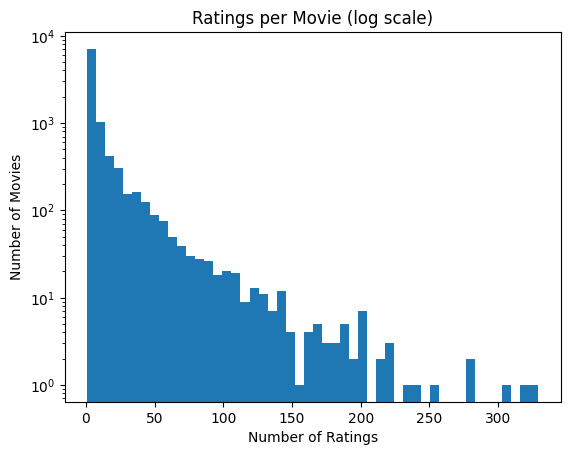

In [9]:
# Rating per movie distribution (plot)
plt.hist(ratings_per_movie, bins=50, log=True)
plt.title('Ratings per Movie (log scale)')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Movies')

In [10]:
#Summary Table:
summary = pd.DataFrame({
    'Metric': ['Total Ratings', 'Unique Users', 'Unique Movies',
               'Avg Ratings per User', 'Avg Ratings per Movie',
               'Positive Interactions (≥4.0)', 'Graph Sparsity'],
    'Value': [100836, 610, 9724,
              round(ratings.groupby('userId').size().mean(), 1),
              round(ratings_per_movie.mean(), 1),
              '48,580 (48.2%)', '98.30%']
})
print(summary.to_string(index=False))

                      Metric          Value
               Total Ratings         100836
                Unique Users            610
               Unique Movies           9724
        Avg Ratings per User          165.3
       Avg Ratings per Movie           10.4
Positive Interactions (≥4.0) 48,580 (48.2%)
              Graph Sparsity         98.30%
